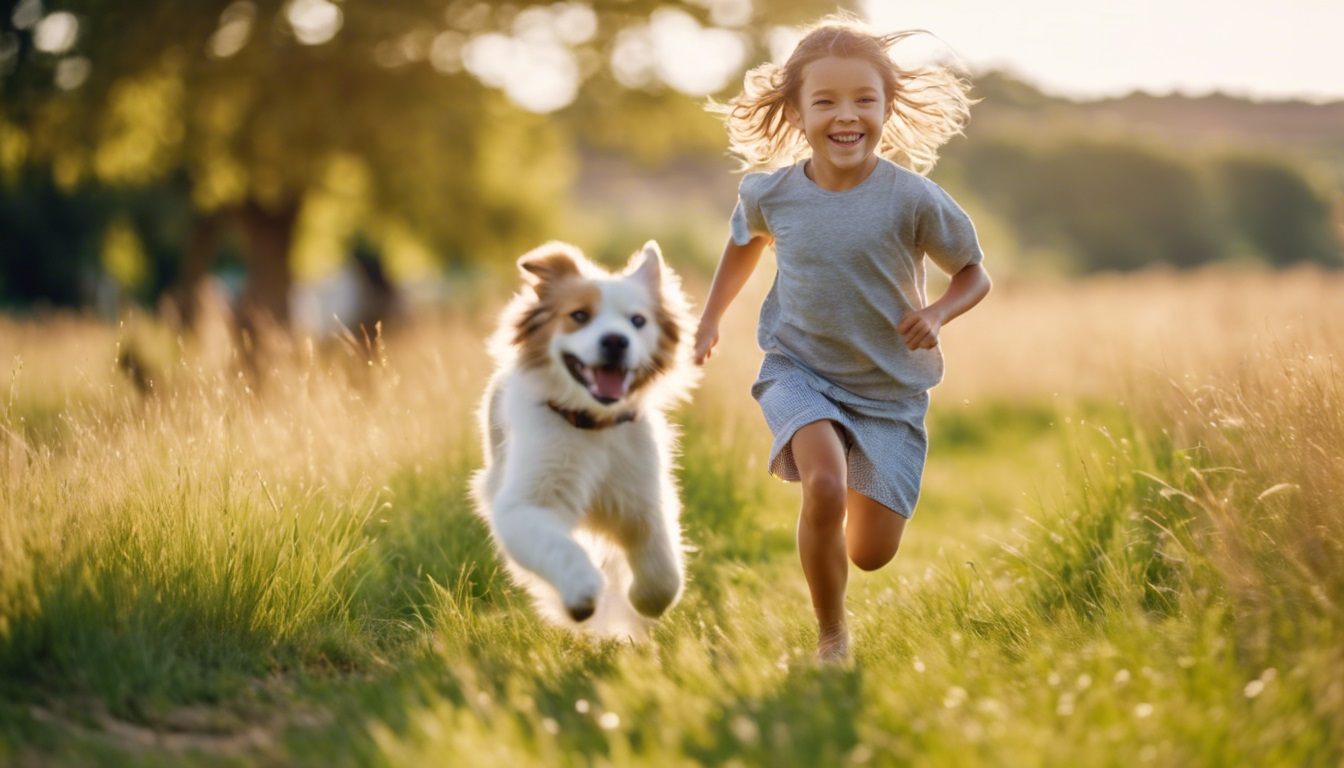

קבוצה מס.3 דניס מרצ'נקו
https://www.allatok.info/search.php?language=en&species=kutya


In [353]:
import pandas as pd
import matplotlib.pyplot as plt
import itertools
# from scipy.stats import chi2_contingency
from plotly.subplots import make_subplots
import plotly.express as px
import numpy as np
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import array as arr
import plotly.graph_objects as go
from IPython.display import display, HTML


Information on data:

The purpose of the project is to show trends that exist in dog adoption data and provide a number of important conclusions arising from the data.
The data was collected in Hungary from 2004-2019 , The data was taken from the kaggle website.

In [356]:
url = 'https://raw.githubusercontent.com/DenisMarcher/Data-Science-Project/refs/heads/main/ShelterDogs.csv'
df = pd.read_csv(url)
df.shape

(2937, 19)

In [357]:
df.columns

Index(['ID', 'name', 'age', 'sex', 'breed', 'date_found', 'adoptable_from',
       'posted', 'color', 'coat', 'size', 'neutered', 'housebroken',
       'likes_people', 'likes_children', 'get_along_males',
       'get_along_females', 'get_along_cats', 'keep_in'],
      dtype='object')

deleting several columns without information 

In [359]:
df = df.drop(columns=['ID', 'name', 'posted'])
df.columns

Index(['age', 'sex', 'breed', 'date_found', 'adoptable_from', 'color', 'coat',
       'size', 'neutered', 'housebroken', 'likes_people', 'likes_children',
       'get_along_males', 'get_along_females', 'get_along_cats', 'keep_in'],
      dtype='object')

In [360]:
df_columns = df.columns
print(df_columns)

Index(['age', 'sex', 'breed', 'date_found', 'adoptable_from', 'color', 'coat',
       'size', 'neutered', 'housebroken', 'likes_people', 'likes_children',
       'get_along_males', 'get_along_females', 'get_along_cats', 'keep_in'],
      dtype='object')


Wrangling data

In [362]:
datatype = pd.DataFrame(df.dtypes, columns=['Data Types'])
Null_Count = pd.DataFrame(df.isnull().sum(), columns=['Null Count'])
data_table = pd.concat([datatype, Null_Count], axis='columns')
data_table 


,Data Types,Null Count
age,float64,0
sex,object,0
breed,object,0
date_found,object,0
adoptable_from,object,0
color,object,0
coat,object,0
size,object,0
neutered,object,1085
housebroken,object,2477


In [363]:
# Convert the date columns to datetime type
df['adoptable_from'] = pd.to_datetime(df['adoptable_from'])
df['date_found'] = pd.to_datetime(df['date_found'])

In [364]:
df['Days_before_adoption'] = (df['adoptable_from'] - df['date_found']).dt.days
# change values in intesger
# and change values from minus to 0
df['Days_before_adoption'] = df['Days_before_adoption'].apply(lambda x: max(x, 0)).astype(int)

In [365]:
df = df[df['neutered'].notna()]
df.shape


(1852, 17)

Noisy data

Checking the parameters so that they are within a reasonable range

In [368]:
age_average = df['age'].mean()
age_average

8.644470842332614

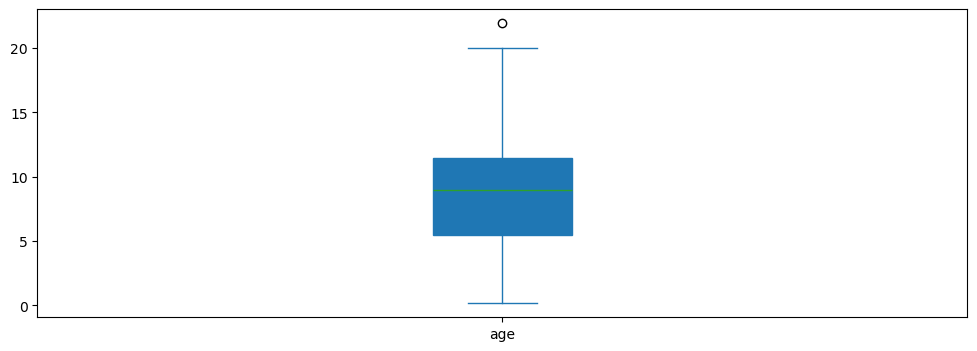

In [369]:
Interesting_columns = ["age"]
Reasonable_Range = df.filter(Interesting_columns).select_dtypes(include=np.number)

# Box plot
Reasonable_Range.plot(subplots=True, layout=(1, len(Interesting_columns)), kind='box', figsize=(12, 4), patch_artist=True)
plt.subplots_adjust(wspace=0.3)
plt.show()

In [370]:
value_counts = df['Days_before_adoption'].value_counts(dropna=False).reset_index()
value_counts.head(10) 

,Days_before_adoption,count
0,0,1501
1,15,71
2,1,36
3,2,10
4,62,8
5,3,8
6,38,8
7,31,7
8,4,7
9,23,6


In [371]:
features = ['age', 'sex', 'Days_before_adoption',
        'coat', 'size', 'neutered', 'housebroken',
       'likes_people', 'likes_children', 'get_along_males',
        'get_along_cats', 'keep_in']
small_fit = pd.get_dummies(df[features])
with_corr= small_fit.corr()
with_corr


,age,Days_before_adoption,sex_female,sex_male,coat_long,coat_medium,coat_short,coat_wirehaired,size_large,size_medium,...,likes_people_yes,likes_children_no,likes_children_yes,get_along_males_no,get_along_males_yes,get_along_cats_no,get_along_cats_yes,keep_in_both flat and garden,keep_in_flat,keep_in_garden
age,1.000000,-0.000796,0.008382,-0.008382,0.026381,0.051226,-0.044211,-0.020353,0.155200,-0.032868,...,0.034514,0.056202,-0.091118,0.104166,-0.042472,-0.011988,-0.142099,-0.011194,-0.115156,0.163589
Days_before_adoption,-0.000796,1.000000,-0.010950,0.010950,0.045734,-0.025391,0.013602,-0.028029,0.045895,-0.025184,...,0.057563,-0.017535,-0.004154,0.012537,0.044263,-0.015304,-0.027935,-0.035693,-0.022653,0.150556
sex_female,0.008382,-0.010950,1.000000,-1.000000,-0.044741,-0.067152,0.120635,-0.072282,-0.049790,0.029215,...,0.042571,-0.021866,0.014840,-0.178889,0.225980,-0.028772,-0.001873,0.059354,0.029344,-0.042630
sex_male,-0.008382,0.010950,-1.000000,1.000000,0.044741,0.067152,-0.120635,0.072282,0.049790,-0.029215,...,-0.042571,0.021866,-0.014840,0.178889,-0.225980,0.028772,0.001873,-0.059354,-0.029344,0.042630
coat_long,0.026381,0.045734,-0.044741,0.044741,1.000000,-0.124029,-0.370091,-0.077092,0.040666,-0.018906,...,-0.122977,0.026371,-0.043710,-0.025163,-0.081076,-0.020652,-0.058510,-0.103555,0.019286,-0.002107
coat_medium,0.051226,-0.025391,-0.067152,0.067152,-0.124029,1.000000,-0.680681,-0.141790,0.063164,-0.022233,...,-0.002885,0.080645,-0.017490,0.033150,-0.030493,-0.019920,0.020156,-0.073933,0.007228,0.042052
coat_short,-0.044211,0.013602,0.120635,-0.120635,-0.370091,-0.680681,1.000000,-0.423088,-0.043753,0.029415,...,0.067892,-0.072168,0.038121,-0.014201,0.082772,0.021700,0.010611,0.120659,0.015429,-0.075357
coat_wirehaired,-0.020353,-0.028029,-0.072282,0.072282,-0.077092,-0.141790,-0.423088,1.000000,-0.050897,-0.002142,...,-0.003233,-0.014098,-0.001791,-0.000342,-0.026886,0.009412,0.005156,-0.010213,-0.054090,0.071804
size_large,0.155200,0.045895,-0.049790,0.049790,0.040666,0.063164,-0.043753,-0.050897,1.000000,-0.653358,...,-0.020134,0.050368,-0.022601,0.098844,-0.063917,0.027646,-0.046152,-0.076345,-0.114905,0.197424
size_medium,-0.032868,-0.025184,0.029215,-0.029215,-0.018906,-0.022233,0.029415,-0.002142,-0.653358,1.000000,...,-0.009522,-0.057074,-0.032689,-0.043545,-0.005346,0.002349,-0.045597,0.030778,-0.097928,-0.030497


<Axes: >

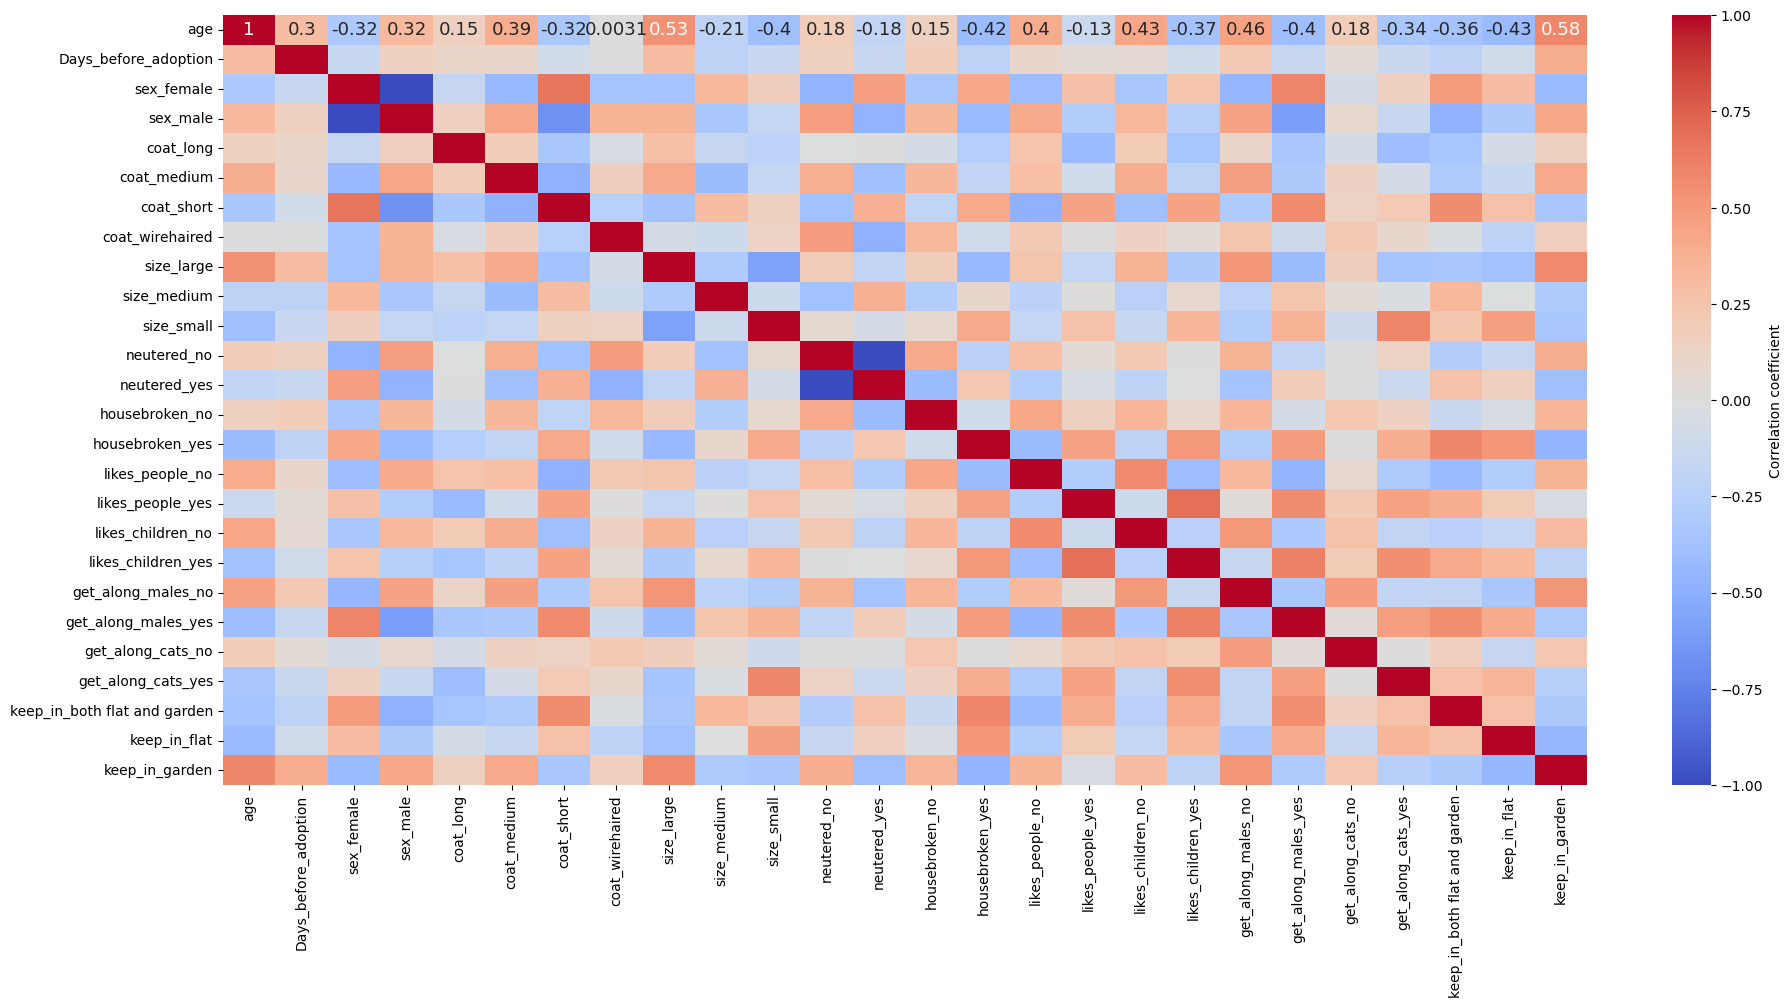

In [372]:
plt.figure(figsize=(22,10))
correlation_matrix = with_corr.corr(method = 'kendall').round(5)
sns.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm',annot_kws={'size': 13} , xticklabels=with_corr.columns, yticklabels=with_corr.columns, 
            cbar_kws={'label': 'Correlation coefficient'})

גיל אימוץ ממוצע 

In [374]:
average_age = df['age'].mean()
average_age

8.644470842332614

In [375]:
# כלב רועה גרמני 
German_Shepherd_Dog_average_age = df[df['breed'] == 'German Shepherd Dog']['age'].mean()
German_Shepherd_Dog_average_age

10.958

In [376]:
# כלב רועה גרמני מעורב 
German_Shepherd_Dog_Mix_average_age = df[df['breed'] == 'German Shepherd Dog Mix']['age'].mean()
German_Shepherd_Dog_Mix_average_age

10.097360000000002

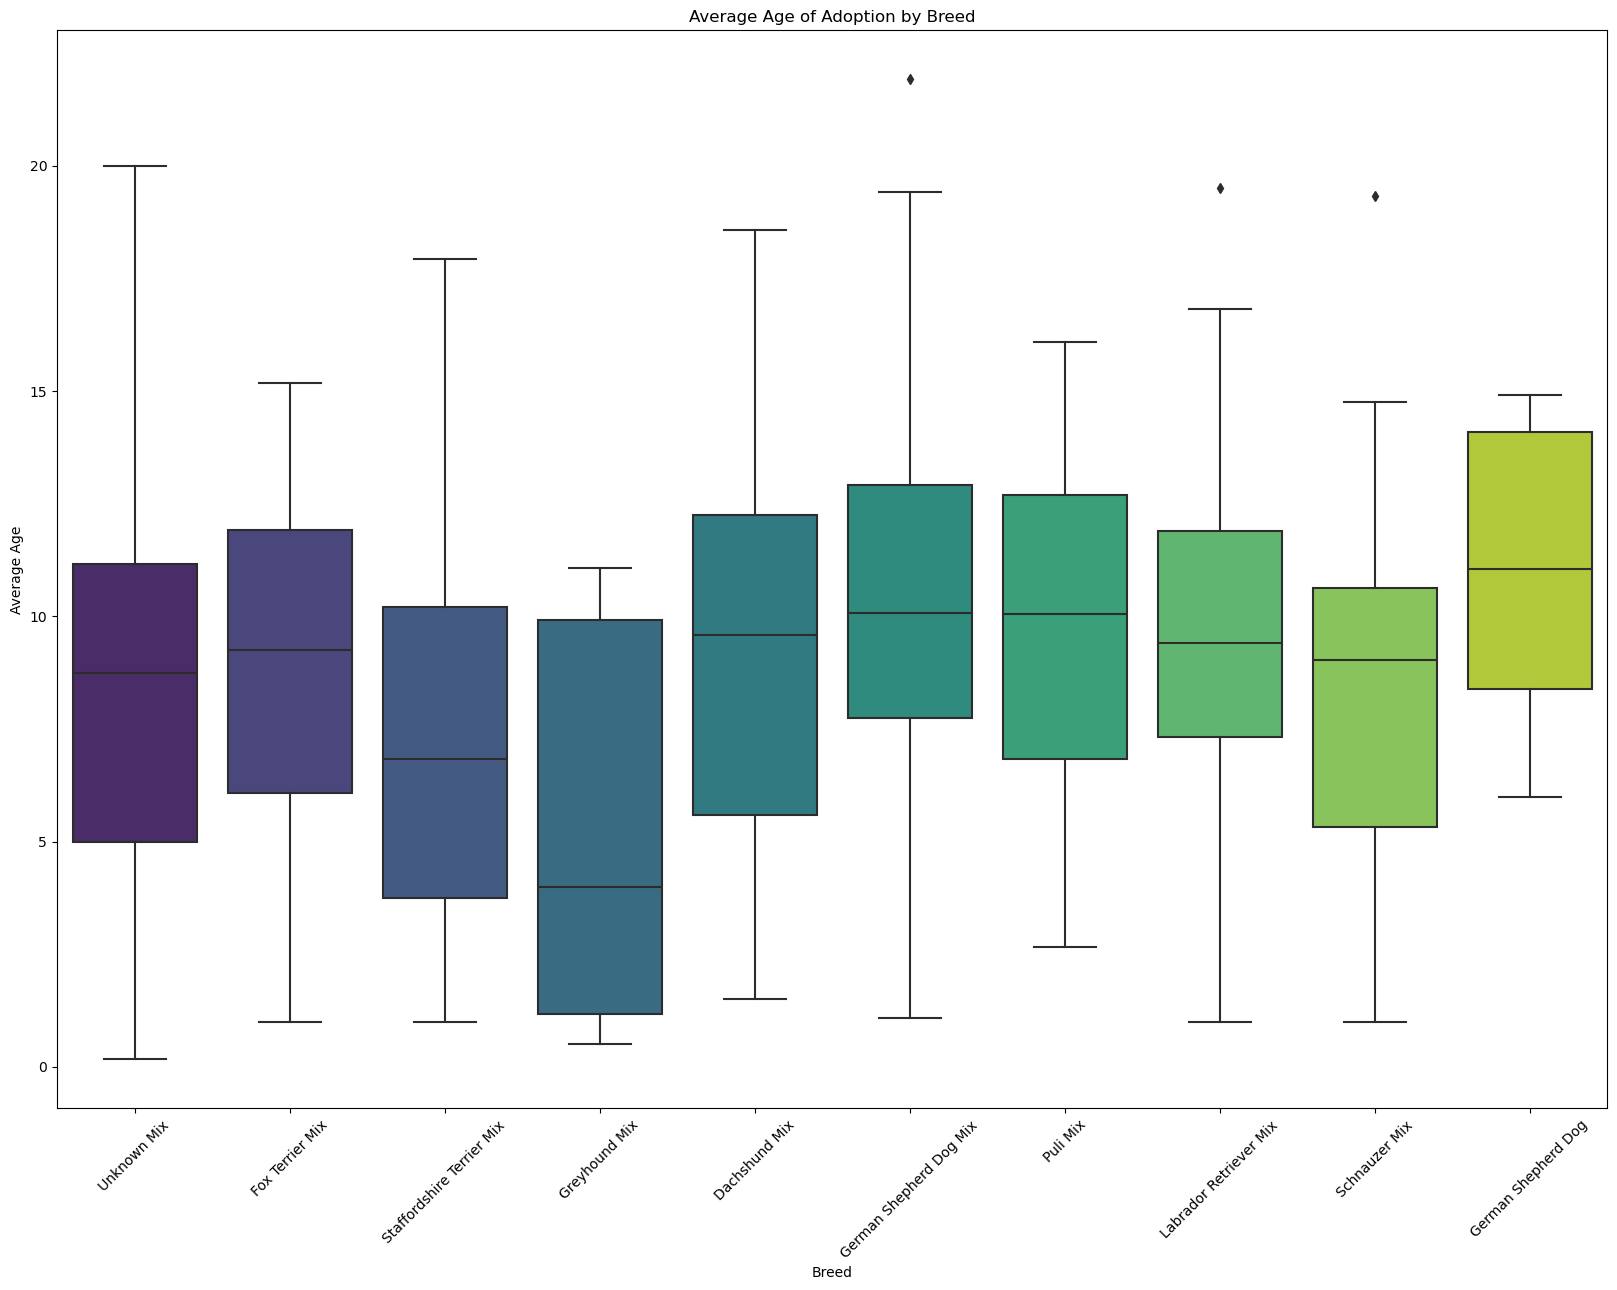

In [377]:
# יצירת גרף עמודות
top_breeds = df['breed'].value_counts().head(10).index
filtered_df = df[df['breed'].isin(top_breeds)]

plt.figure(figsize=(20, 14))
sns.boxplot(x='breed', y='age', data=filtered_df, palette='viridis')
plt.title('Average Age of Adoption by Breed')
plt.xlabel('Breed')
# plt.ylim(0, 20)
plt.ylabel('Average Age')
plt.xticks(rotation=45)
plt.show()

מסקנה א: מהנתונים עולה כי בעלי כלבים נוטים להעביר את כלבם לאימוץ בגיל ממוצע של 8.6 שנים, ללא הבחנה בין זכר לנקבה. עם זאת, ישנם יוצאים מן הכלל, ובפרט כלב מסוג רועה גרמני טהור, שמועבר לאימוץ בגיל ממוצע של 11 שנה – גיל גבוה באופן משמעותי מהשאר.

חקירה העדפת אימוץ על פי גזע בהתאם לזמן שהייה במתקן האימוץ 

In [379]:
adoptable_day_average = df['Days_before_adoption'].mean()
adoptable_day_average

18.510799136069114

In [380]:
# חישוב ממוצע ומקסימום לפי סוג הגזע
result = df.groupby('breed')['Days_before_adoption'].agg(['mean','count'])
top_10_breeds = result.nlargest(10, 'count')
top_10_breeds


,mean,count
breed,,
Unknown Mix,24.607330,955
German Shepherd Dog Mix,21.792000,125
Dachshund Mix,9.658824,85
Labrador Retriever Mix,3.462963,54
Staffordshire Terrier Mix,12.418605,43
Schnauzer Mix,13.307692,26
Greyhound Mix,10.680000,25
Puli Mix,16.750000,24
Fox Terrier Mix,17.285714,21


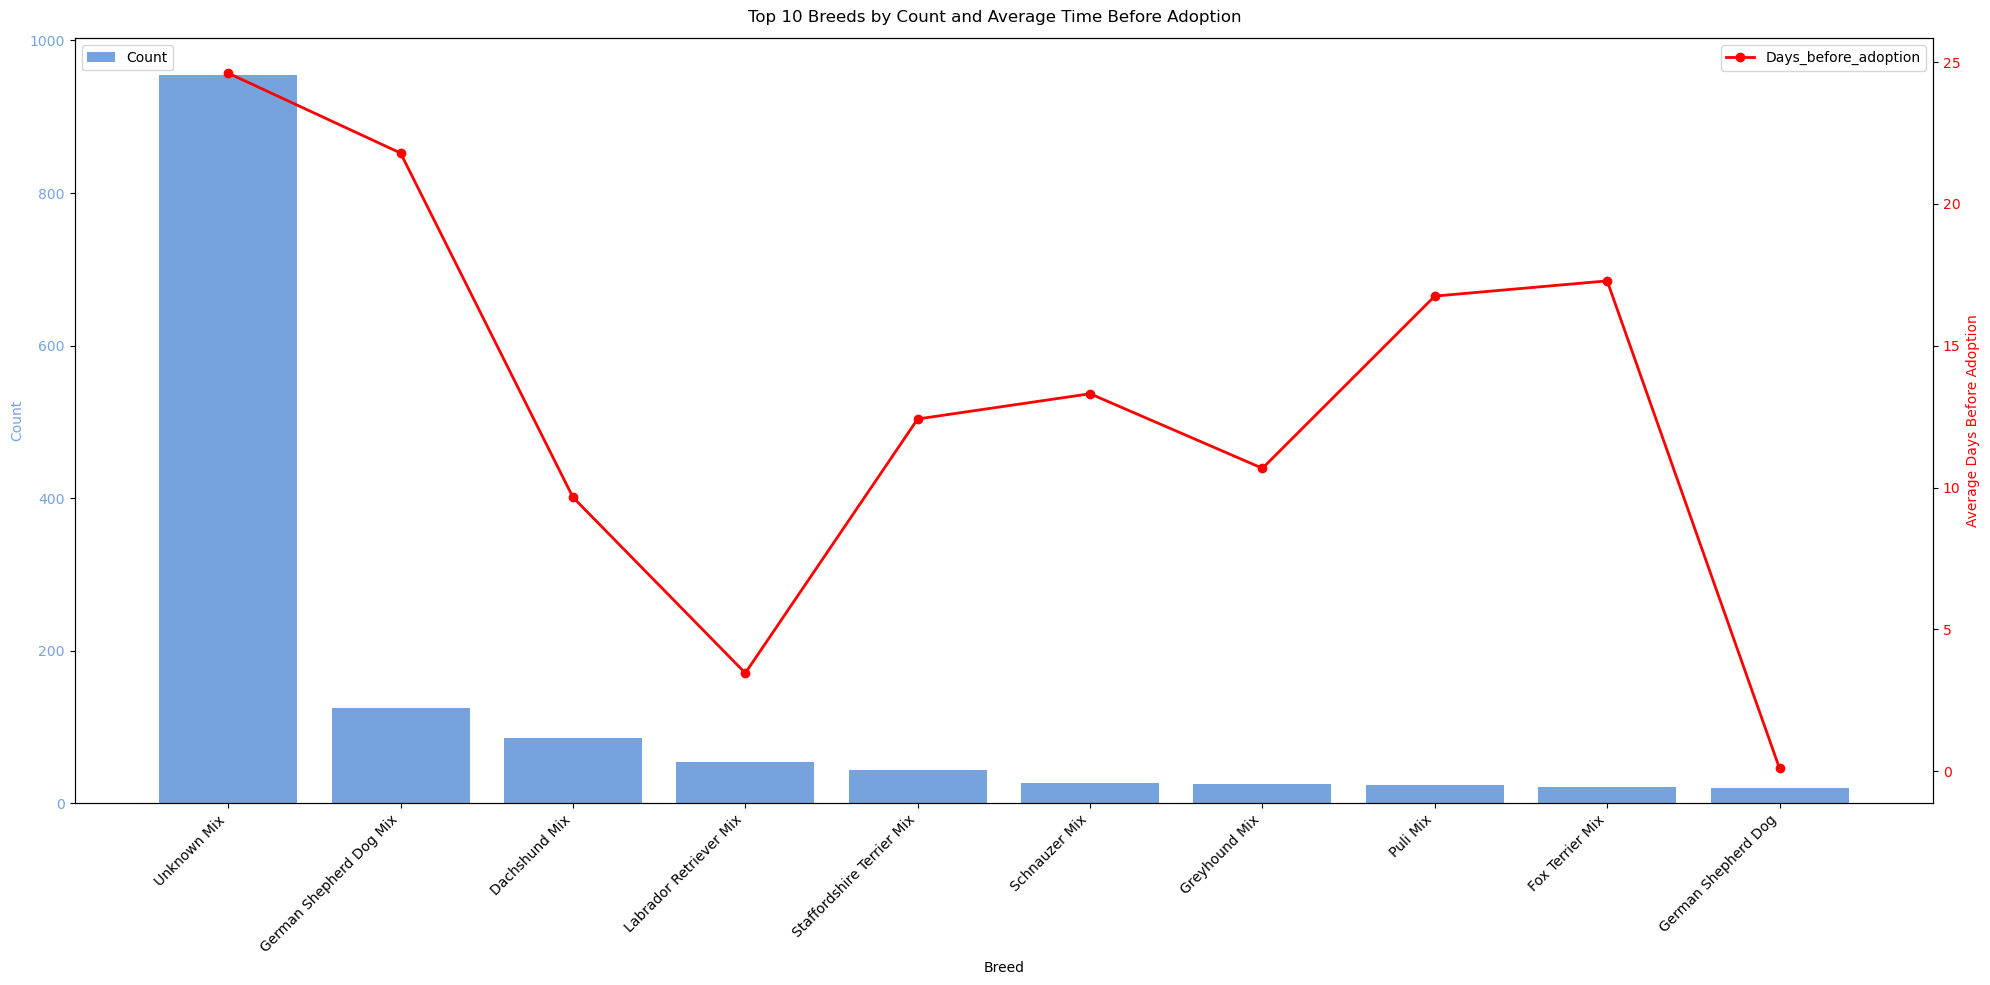

In [381]:
# הגדרת צבעים
color_count = '#76A3DE'
color_mean = 'red'

# יצירת נתונים
result = df.groupby('breed')['Days_before_adoption'].agg(['mean', 'count'])
top_10_count = result.nlargest(10, 'count')

# הגדרת גרף
fig, ax1 = plt.subplots(figsize=(20, 10))

# גרף ראשון (ציר X = breed, ציר Y = count)
bars = ax1.bar(top_10_count.index, top_10_count['count'], color=color_count, label='Count')
ax1.set_ylabel('Count', color=color_count)
ax1.tick_params(axis='y', labelcolor=color_count)
ax1.set_xlabel('Breed')
ax1.set_xticks(range(len(top_10_count.index)))
ax1.set_xticklabels(top_10_count.index, rotation=45, ha='right')


# גרף שני (ציר X = breed, ציר Y = mean of Days_before_adoption)
ax2 = ax1.twinx()
ax2.plot(top_10_count.index, top_10_count['mean'], color=color_mean, marker='o', linewidth=2, label='Days_before_adoption')
ax2.set_ylabel('Average Days Before Adoption', color=color_mean)
ax2.tick_params(axis='y', labelcolor=color_mean)

# כותרת ומקרא
fig.suptitle('Top 10 Breeds by Count and Average Time Before Adoption')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

חקירת העדפת אימוץ על פי מבנה גוף 

In [383]:
size_count = df.groupby(['size', 'sex'])['Days_before_adoption'].agg(['mean', 'count'])
size_count

mean  count
size   sex                     
large  female  26.115385    130
       male    29.254630    216
medium female  17.155598    527
       male    16.283604    677
small  female   8.985075    134
       male    19.636905    168

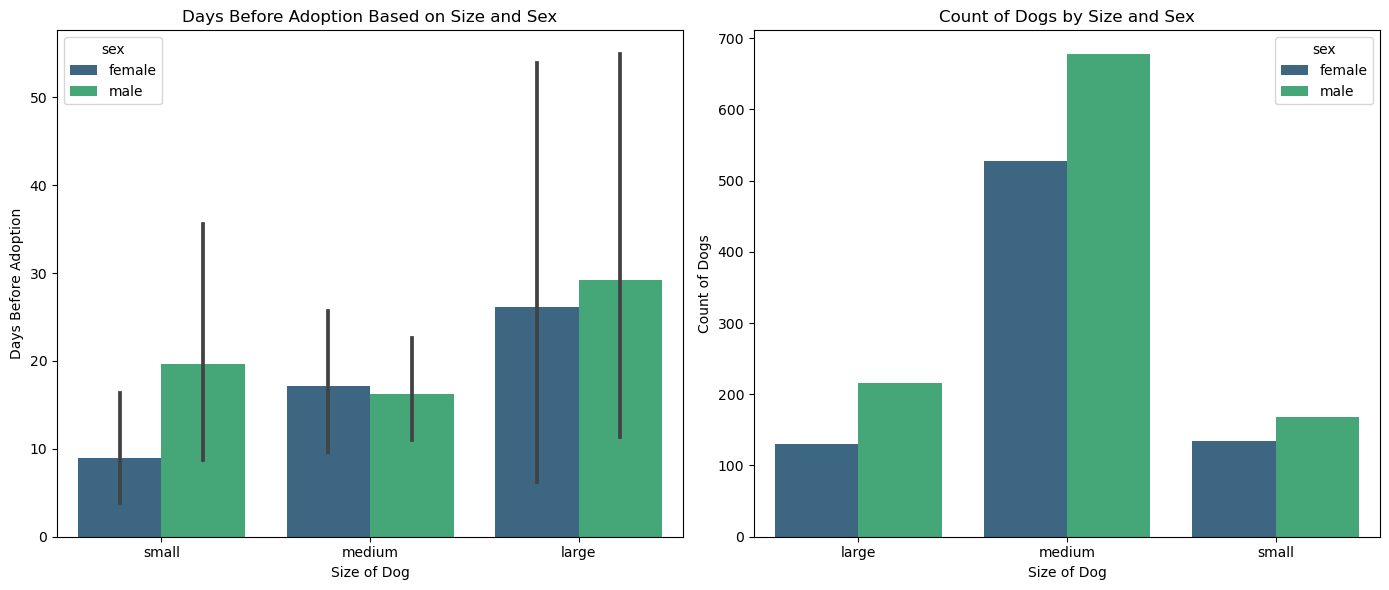

In [384]:
# חישוב ממוצע ומספר ימים לפני האימוץ לפי גודל ומין
size_count = df.groupby(['size', 'sex'])['Days_before_adoption'].agg(['mean', 'count']).reset_index()

# יצירת גרפים
plt.figure(figsize=(14, 6))

# גרף ראשון: Barplot מראה את הקשר בין גודל למספר הימים לפני האימוץ
plt.subplot(1, 2, 1)
sns.barplot(x='size', y='Days_before_adoption', hue='sex', data=df, palette='viridis')
plt.xlabel('Size of Dog')
plt.ylabel('Days Before Adoption')
plt.title('Days Before Adoption Based on Size and Sex')

# גרף שני: Barplot למספר הכלבים לפי גודל ומין
plt.subplot(1, 2, 2)
sns.barplot(x='size', y='count', hue='sex', data=size_count, palette='viridis')
plt.xlabel('Size of Dog')
plt.ylabel('Count of Dogs')
plt.title('Count of Dogs by Size and Sex')
plt.xticks(rotation=0)

# הצגת הגרפים
plt.tight_layout()
plt.show()


מסקנה ג : קיימת העדפה ברורה לאימוץ כלבים בעלי מבנה גוף קטן עד בינוני 

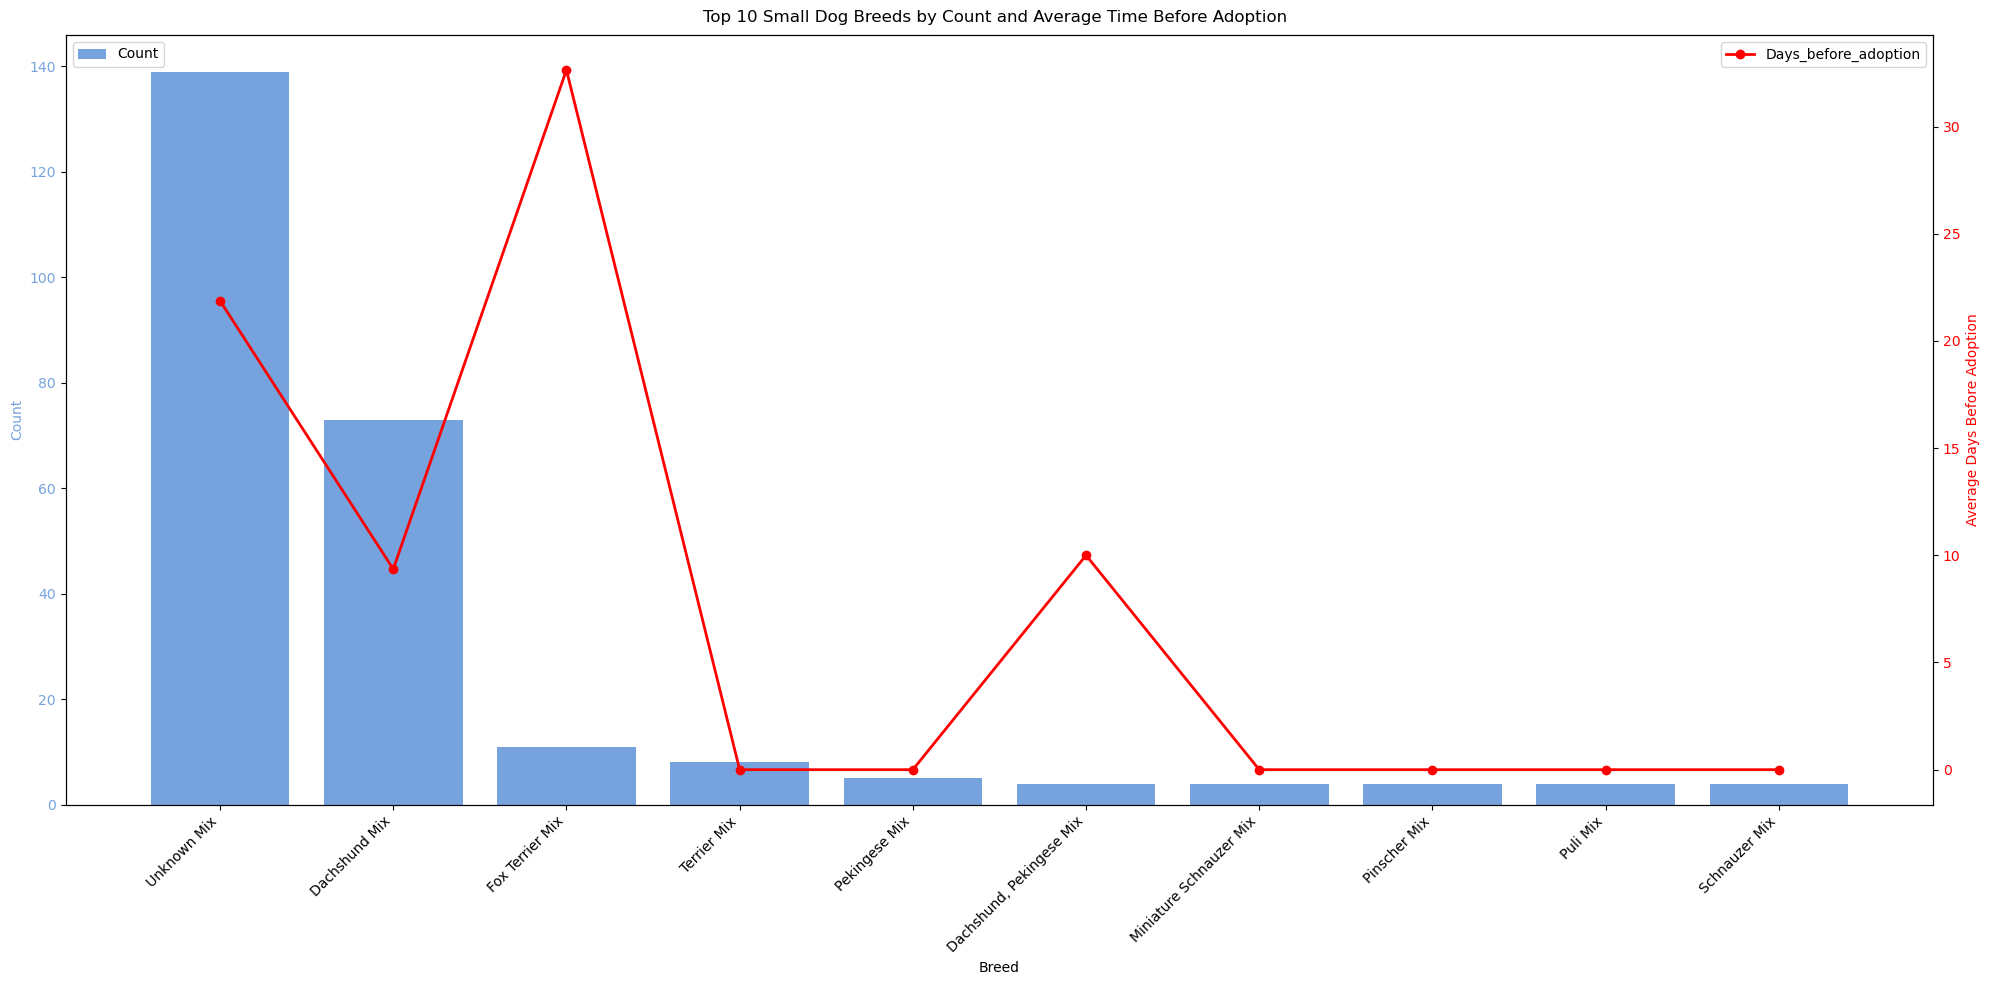

In [426]:
# הגדרת צבעים
color_count = '#76A3DE'
color_mean = 'red'

small_dogs = df[df['size'] == 'small']

result_small = small_dogs.groupby('breed')['Days_before_adoption'].agg(['mean', 'count'])
top_10_small = result_small.nlargest(10, 'count')

# הגדרת גרף
fig, ax1 = plt.subplots(figsize=(20, 10))

# גרף ראשון (ציר X = breed, ציר Y = count)
bars = ax1.bar(top_10_small.index, top_10_small['count'], color=color_count, label='Count')
ax1.set_ylabel('Count', color=color_count)
ax1.tick_params(axis='y', labelcolor=color_count)
ax1.set_xlabel('Breed')
ax1.set_xticks(range(len(top_10_small.index)))
ax1.set_xticklabels(top_10_small.index, rotation=45, ha='right')


# גרף שני (ציר X = breed, ציר Y = mean of Days_before_adoption)
ax2 = ax1.twinx()
ax2.plot(top_10_small.index, top_10_small['mean'], color=color_mean, marker='o', linewidth=2, label='Days_before_adoption')
ax2.set_ylabel('Average Days Before Adoption', color=color_mean)
ax2.tick_params(axis='y', labelcolor=color_mean)

# כותרת ומקרא
fig.suptitle('Top 10 Small Dog Breeds by Count and Average Time Before Adoption')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

חקירת העדפות האימוץ בהתבסס על מצב העיקור של הכלב (מעוקר או לא מעוקר)

In [386]:
neutered_count = df.groupby(['neutered'])['Days_before_adoption'].agg(['mean', 'count'])
neutered_count

,mean,count
neutered,,
no,23.727532,701
yes,15.333623,1151


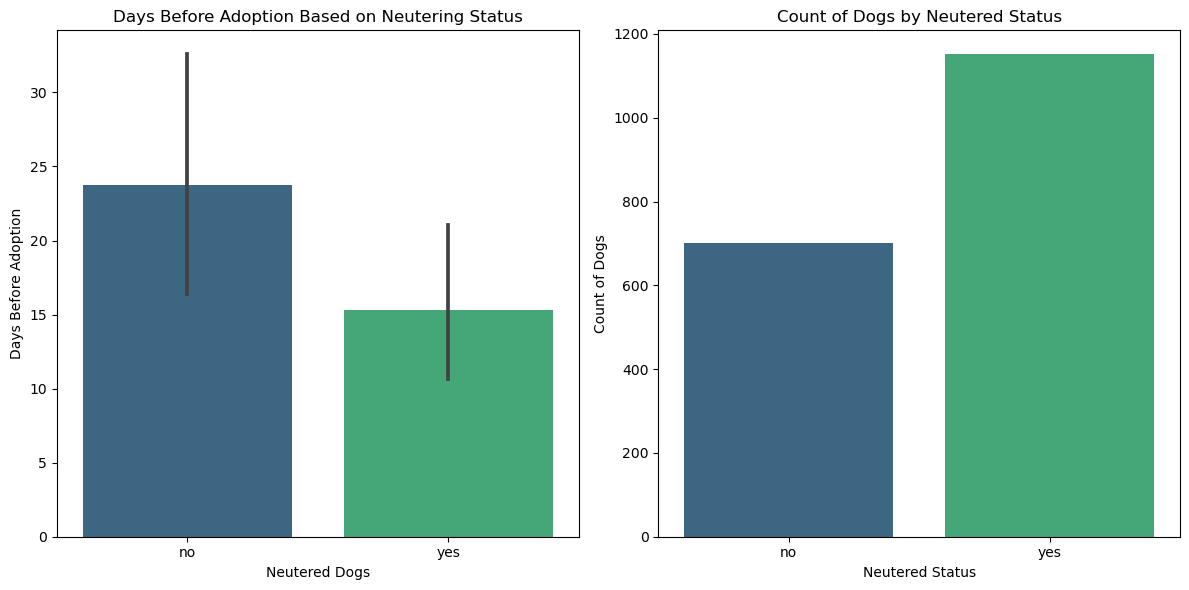

In [388]:
plt.figure(figsize=(12, 6))

# First subplot: Barplot showing the relationship between neutering status and days before adoption
plt.subplot(1, 2, 1)
sns.barplot(x='neutered', y='Days_before_adoption', data=df, palette='viridis')
plt.xlabel('Neutered Dogs')
plt.ylabel('Days Before Adoption')
plt.title('Days Before Adoption Based on Neutering Status')

# Second subplot: Barplot for count of neutered dogs
plt.subplot(1, 2, 2)
sns.barplot(x=neutered_count.index, y=neutered_count['count'], palette='viridis')
plt.xlabel('Neutered Status')
plt.ylabel('Count of Dogs')
plt.title('Count of Dogs by Neutered Status')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

מסקנה ד: קיימת העדפה ברורה לאימוץ כלבים מעוקרים (ללא פירוט זכר\נקבה) שהרי כמות הכלבים המעוקרים גבוהה יותר אך זמן שהייתם לפני האימוץ הוא קצר יותר

חקירת העדפת אימוץ ביחס לעונות השנה 

In [430]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'  # חורף
    elif month in [3, 4, 5]:
        return 'Spring'  # אביב
    elif month in [6, 7, 8]:
        return 'Summer'  # קיץ
    else:
        return 'Fall'  # סתיו

df['season'] = df['adoptable_from'].dt.month.apply(get_season)
season_count = df['season'].value_counts()

print(season_count)

season
Winter    515
Spring    493
Fall      433
Summer    411
Name: count, dtype: int64


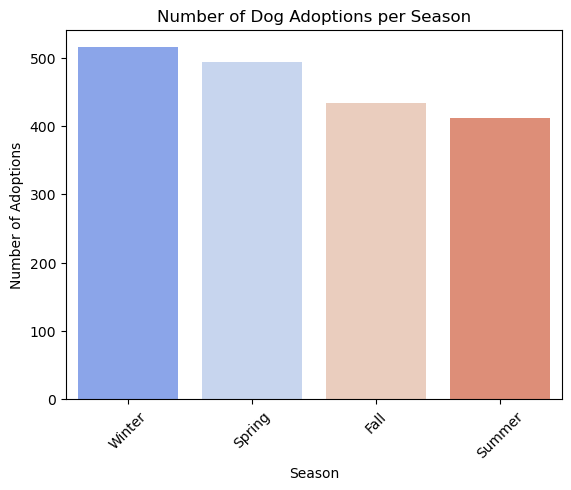

In [457]:
# יצירת גרף barplot
sns.barplot(x=season_count.index, y=season_count.values, palette='coolwarm')

# הוספת כותרת ותיוגים
plt.title('Number of Dog Adoptions per Season')
plt.xlabel('Season')
plt.ylabel('Number of Adoptions')

# סיבוב התוויות של הציר ה-X ל-45 מעלות כדי להקל על הקריאה
plt.xticks(rotation=45)

# הצגת הגרף
plt.show()

מסקנה ה : רואים שקיימת העדפה לאימוץ כלבים בעיקר בחורף ופחות בקיץ אולי מהסיבה שמשפחות יוצאות לטייל ופחות פנויות לאמץ כלב  

מסקנה כללית : אנשים מעדיפים לאמץ כלבים קטנים מעוקרים  בעלי גזע ידוע בעיקר בחורף 

המלצה : על פי המסקנות לעיל מסתבר, שכלבים מעוקרים שהו פחות זמן במתקן לפני העברתם לאימוץ ולכן להגברת עידוד אימוץ כלבים יש לבצע פעולת עיקור\סירוס לכל אוכלסית הכלבים